In [1]:
import glob

folder = "../outputs/planning_scale/instruct/*"
glob.glob(folder)

['../outputs/planning_scale/instruct/prompt_1',
 '../outputs/planning_scale/instruct/prompt_10',
 '../outputs/planning_scale/instruct/prompt_2',
 '../outputs/planning_scale/instruct/prompt_3',
 '../outputs/planning_scale/instruct/prompt_4',
 '../outputs/planning_scale/instruct/prompt_5',
 '../outputs/planning_scale/instruct/prompt_6',
 '../outputs/planning_scale/instruct/prompt_7',
 '../outputs/planning_scale/instruct/prompt_8',
 '../outputs/planning_scale/instruct/prompt_9']

In [ ]:
for f in glob.glob(folder):
    token_files = glob.glob(f + "/*")
    print(f, len(token_files))

../outputs/planning_scale/instruct/prompt_1 49
../outputs/planning_scale/instruct/prompt_10 18
../outputs/planning_scale/instruct/prompt_2 15
../outputs/planning_scale/instruct/prompt_3 44
../outputs/planning_scale/instruct/prompt_4 17
../outputs/planning_scale/instruct/prompt_5 45
../outputs/planning_scale/instruct/prompt_6 48
../outputs/planning_scale/instruct/prompt_7 47
../outputs/planning_scale/instruct/prompt_8 19
../outputs/planning_scale/instruct/prompt_9 47


In [4]:
import json

timings = {}

for fi in glob.glob(folder):
    token_files = glob.glob(fi + "/*")
    for tf in token_files:
        metadata_file = tf + "/metadata.json"
        with open(metadata_file, "r") as f:
            metadata = json.load(f)
        prompt_idx = fi.split("prompt_")[-1]
        token_idx = tf.split("token_")[-1]
        timings[(prompt_idx, token_idx)] = metadata["timings"]

In [6]:
len(timings)

349

In [8]:
timings[timings.keys().__iter__().__next__()]

{'circuit_discovery_s': 35.06870836671442,
 'clustering_s_gather': 2.759759592823684,
 'clustering_s_neuronpedia': 0.21460858918726444,
 'clustering_s': 2.9743926199153066,
 'steering_sweep_s': 10.599514462053776,
 'per_position_total_s': 231.81886095367372,
 'per_position_checked': 90.0,
 'total_s': 280.4652407374233}

In [10]:
## get average time per token.
all_times = [x["total_s"] for x in timings.values()]
avg_time = sum(all_times) / len(all_times)
avg_time

207.08655141011354

In [11]:
## get average time per file.
time_per_file = {}
for (prompt_idx, token_idx), timing in timings.items():
    if prompt_idx not in time_per_file:
        time_per_file[prompt_idx] = 0
    time_per_file[prompt_idx] += timing["total_s"]

all_file_times = list(time_per_file.values())
avg_file_time = sum(all_file_times) / len(all_file_times)
avg_file_time

7227.320644212962

In [12]:
## max and min file time.
max_file_time = max(all_file_times)
min_file_time = min(all_file_times)
max_file_time, min_file_time

(12967.782033251598, 1442.7451469469815)

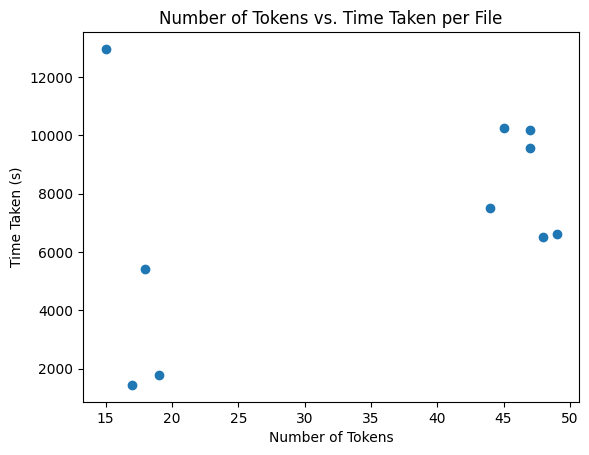

In [13]:
## get number of tokens vs. time consumed per file.
tokens_per_file = {}
for (prompt_idx, token_idx), timing in timings.items():
    if prompt_idx not in tokens_per_file:
        tokens_per_file[prompt_idx] = 0
    tokens_per_file[prompt_idx] += 1

import matplotlib.pyplot as plt
num_tokens = list(tokens_per_file.values())
plt.scatter(num_tokens, all_file_times)
plt.xlabel("Number of Tokens")
plt.ylabel("Time Taken (s)")
plt.title("Number of Tokens vs. Time Taken per File")
plt.show()

In [14]:
tokens_per_file, time_per_file

({'1': 49,
  '10': 18,
  '2': 15,
  '3': 44,
  '4': 17,
  '5': 45,
  '6': 48,
  '7': 47,
  '8': 19,
  '9': 47},
 {'1': 6614.187897713855,
  '10': 5417.353277905844,
  '2': 12967.782033251598,
  '3': 7511.591563396156,
  '4': 1442.7451469469815,
  '5': 10242.783651335398,
  '6': 6522.348068090156,
  '7': 10199.099705119617,
  '8': 1785.6373873410048,
  '9': 9569.677711029013})